In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier












 

In [2]:
train  = pd.read_parquet('/kaggle/input/competitions/ct-ds-hiring-april/train.parquet')
test   = pd.read_parquet('/kaggle/input/competitions/ct-ds-hiring-april/test.parquet')
sample = pd.read_parquet('/kaggle/input/competitions/ct-ds-hiring-april/sample_submission.parquet')

print('Train shape :', train.shape)
print('Test shape  :', test.shape)
print('Sample shape:', sample.shape)
print('\nTrain columns:', train.columns.tolist())
print('Test columns :', test.columns.tolist())
print('\nClass distribution:\n', train['target'].value_counts())
print('\nClass proportions:\n', train['target'].value_counts(normalize=True).round(4))

Train shape : (1639424, 7)
Test shape  : (409856, 7)
Sample shape: (50, 2)

Train columns: ['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target']
Test columns : ['ID', 'Date', 'X1', 'X2', 'X3', 'X4', 'X5']

Class distribution:
 target
0    1625386
1      14038
Name: count, dtype: int64

Class proportions:
 target
0    0.9914
1    0.0086
Name: proportion, dtype: float64


In [3]:
print('Missing in train:\n', train.isnull().sum())
print('\nMissing in test:\n', test.isnull().sum())

train.describe()

Missing in train:
 Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

Missing in test:
 ID      0
Date    0
X1      0
X2      0
X3      0
X4      0
X5      0
dtype: int64


,Date,X1,X2,X3,X4,X5
count,1639424,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06
mean,2022-12-03 07:23:43.817145600,1.139258e+00,5.488189e+00,4.110388e+32,2.706323e+29,1.187219e+00
min,2020-12-16 00:00:00,1.000000e+00,5.412539e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2021-12-10 00:00:00,1.049171e+00,5.480597e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,2022-11-30 00:00:00,1.105171e+00,5.488979e+00,1.000000e+00,1.000000e+00,6.931472e-01
75%,2023-11-23 00:00:00,1.214096e+00,5.496717e+00,1.000000e+00,2.718282e+00,2.890372e+00
max,2024-12-11 00:00:00,4.014850e+00,5.541852e+00,1.651636e+38,5.540622e+34,3.465736e+00
std,NaN,1.391992e-01,1.342811e-02,2.346156e+35,5.812988e+31,1.304814e+00


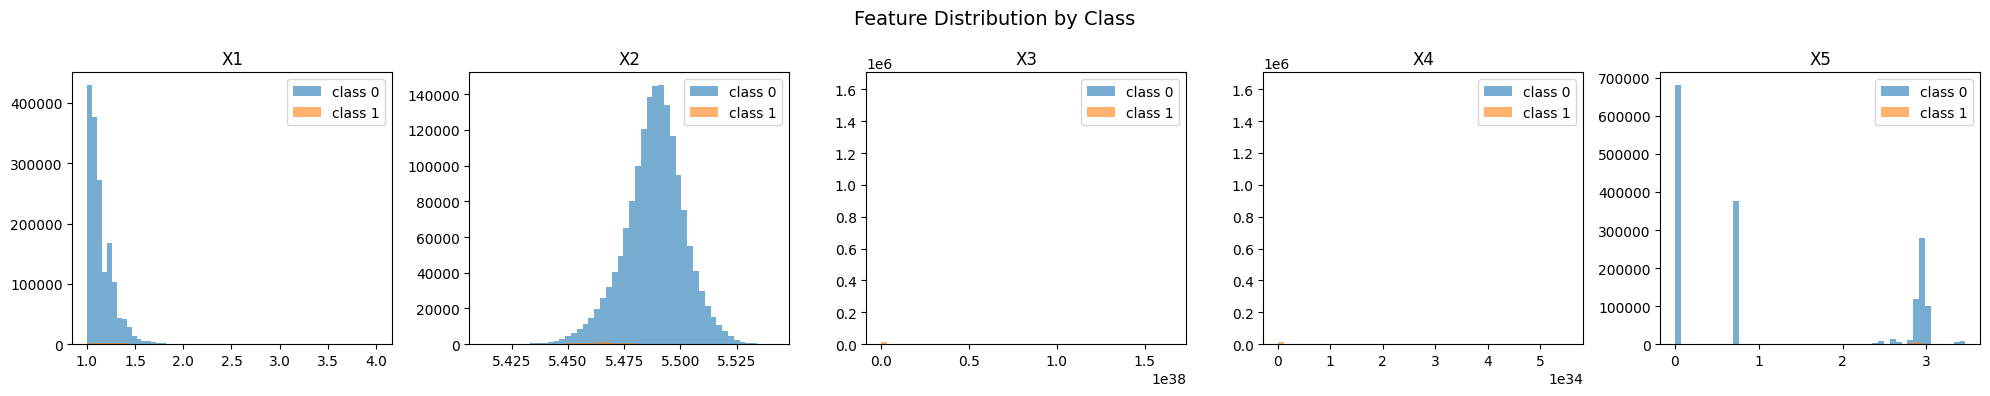

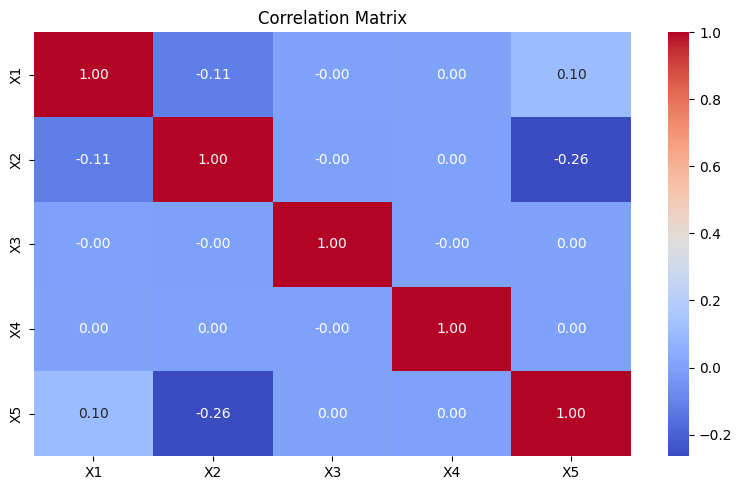

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
sensor_cols = ['X1', 'X2', 'X3', 'X4', 'X5']

for i, col in enumerate(sensor_cols):
    for cls in [0, 1]:
        mask = train['target'].astype(int) == cls
        axes[i].hist(train[mask][col], bins=50, alpha=0.6, label=f'class {cls}')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distribution by Class', fontsize=14)
plt.tight_layout()
plt.show()


num_cols = train.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(8, 5))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
def engineer_features(df, is_train=True):
    df = df.copy()

    
    df['year']      = df['Date'].dt.year
    df['month']     = df['Date'].dt.month
    df['day']       = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['quarter']   = df['Date'].dt.quarter
    df['dayofyear'] = df['Date'].dt.dayofyear
    df.drop(columns=['Date'], inplace=True)

    
    if 'ID' in df.columns:
        df.drop(columns=['ID'], inplace=True)

    
    sensor_cols = ['X1', 'X2', 'X3', 'X4', 'X5']

    
    df['row_mean']  = df[sensor_cols].mean(axis=1)
    df['row_std']   = df[sensor_cols].std(axis=1)
    df['row_max']   = df[sensor_cols].max(axis=1)
    df['row_min']   = df[sensor_cols].min(axis=1)
    df['row_range'] = df['row_max'] - df['row_min']

    
    for i in range(len(sensor_cols)):
        for j in range(i + 1, len(sensor_cols)):
            a, b = sensor_cols[i], sensor_cols[j]
            df[f'{a}_{b}_ratio'] = df[a] / (df[b] + 1e-9)
            df[f'{a}_{b}_diff']  = df[a] - df[b]

    return df

train_fe = engineer_features(train, is_train=True)
test_fe  = engineer_features(test,  is_train=False)

print('Train after FE:', train_fe.shape)
print('Test after FE :', test_fe.shape)

Train after FE: (1639424, 37)
Test after FE : (409856, 36)


In [6]:
X = train_fe.drop(columns=['target'])
y = train_fe['target'].astype(int)


test_fe = test_fe[X.columns]

print('X shape   :', X.shape)
print('y shape   :', y.shape)
print('Test shape:', test_fe.shape)
print('\nClass counts:\n', y.value_counts())


scale_pos = int((y == 0).sum() / (y == 1).sum())
print('\nscale_pos_weight for XGB:', scale_pos)

X shape   : (1639424, 36)
y shape   : (1639424,)
Test shape: (409856, 36)

Class counts:
 target
0    1625386
1      14038
Name: count, dtype: int64

scale_pos_weight for XGB: 115


In [7]:
X = X.replace([np.inf, -np.inf], np.nan)
test_fe = test_fe.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())
test_fe = test_fe.fillna(test_fe.median())


print('Inf in X:', np.isinf(X.values).sum())
print('NaN in X:', np.isnan(X.values).sum())
print('Inf in test:', np.isinf(test_fe.values).sum())
print('NaN in test:', np.isnan(test_fe.values).sum())
print('All clean ')

Inf in X: 0
NaN in X: 0
Inf in test: 0
NaN in test: 0
All clean 


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled      = scaler.fit_transform(X)
test_scaled   = scaler.transform(test_fe)

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_scaled, y)

lr_train_preds = lr_model.predict(X_scaled)
lr_test_preds  = lr_model.predict(test_scaled)

print('=== Logistic Regression - Train Report ===')
print(classification_report(y, lr_train_preds, digits=4))

=== Logistic Regression - Train Report ===
              precision    recall  f1-score   support

           0     0.9992    0.9164    0.9560   1625386
           1     0.0865    0.9162    0.1580     14038

    accuracy                         0.9164   1639424
   macro avg     0.5428    0.9163    0.5570   1639424
weighted avg     0.9914    0.9164    0.9492   1639424



In [9]:
submission_lr = pd.DataFrame({
    'ID': test['ID'].values,
    'target': lr_test_preds
})
submission_lr.to_csv('submission_lr.csv', index=False)
print('Saved: submission_lr.csv')
print(submission_lr['target'].value_counts())

Saved: submission_lr.csv
target
0    372480
1     37376
Name: count, dtype: int64


In [10]:
import numpy as np
X = X.replace([np.inf, -np.inf], np.nan)
test_fe = test_fe.replace([np.inf, -np.inf], np.nan)

FLOAT32_MAX = np.finfo(np.float32).max  # 3.4e+38
X = X.clip(-FLOAT32_MAX, FLOAT32_MAX)
test_fe = test_fe.clip(-FLOAT32_MAX, FLOAT32_MAX)


X = X.fillna(X.median())
test_fe = test_fe.fillna(test_fe.median())


print('Max in X    :', X.max().max())
print('Min in X    :', X.min().min())
print('Inf in X    :', np.isinf(X.values).sum())
print('NaN in X    :', np.isnan(X.values).sum())
print('Inf in test :', np.isinf(test_fe.values).sum())
print('NaN in test :', np.isnan(test_fe.values).sum())
print('All clean ')

Max in X    : 3.4028234663852886e+38
Min in X    : -1.6516362549940018e+38
Inf in X    : 0
NaN in X    : 0
Inf in test : 0
NaN in test : 0
All clean 


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X, y)

rf_train_preds = rf_model.predict(X)
rf_test_preds  = rf_model.predict(test_fe)

print('=== Random Forest - Train Report ===')
print(classification_report(y, rf_train_preds, digits=4))

=== Random Forest - Train Report ===
              precision    recall  f1-score   support

           0     0.9995    0.9687    0.9839   1625386
           1     0.2072    0.9481    0.3400     14038

    accuracy                         0.9685   1639424
   macro avg     0.6033    0.9584    0.6619   1639424
weighted avg     0.9928    0.9685    0.9783   1639424



In [12]:
submission_rf = pd.DataFrame({
    'ID': test['ID'].values,
    'target': rf_test_preds
})
submission_rf.to_csv('submission_rf.csv', index=False)
print('Saved: submission_rf.csv')
print(submission_rf['target'].value_counts())

Saved: submission_rf.csv
target
0    394050
1     15806
Name: count, dtype: int64


In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X, y)

xgb_train_preds = xgb_model.predict(X)
xgb_test_preds  = xgb_model.predict(test_fe)

print('=== XGBoost - Train Report ===')
print(classification_report(y, xgb_train_preds, digits=4))

=== XGBoost - Train Report ===
              precision    recall  f1-score   support

           0     0.9998    0.9651    0.9821   1625386
           1     0.1942    0.9746    0.3238     14038

    accuracy                         0.9651   1639424
   macro avg     0.5970    0.9699    0.6530   1639424
weighted avg     0.9929    0.9651    0.9765   1639424



In [14]:
submission_xgb = pd.DataFrame({
    'ID': test['ID'].values,
    'target': xgb_test_preds
})
submission_xgb.to_csv('submission_xgb.csv', index=False)
print('Saved: submission_xgb.csv')
print(submission_xgb['target'].value_counts())

Saved: submission_xgb.csv
target
0    392442
1     17414
Name: count, dtype: int64


In [15]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X, y)

lgb_train_preds = lgb_model.predict(X)
lgb_test_preds  = lgb_model.predict(test_fe)

print('=== LightGBM - Train Report ===')
print(classification_report(y, lgb_train_preds, digits=4))

[LightGBM] [Info] Number of positive: 14038, number of negative: 1625386
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7077
[LightGBM] [Info] Number of data points in the train set: 1639424, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
=== LightGBM - Train Report ===
              precision    recall  f1-score   support

           0     0.9999    0.9735    0.9865   1625386
           1     0.2435    0.9892    0.3908     14038

    accuracy                         0.9736   1639424
   macro avg     0.6217    0.9813    0.6887   1639424
weighted avg     0.9934    0.9736    0.9814   1639424



In [16]:
submission_lgb = pd.DataFrame({
    'ID': test['ID'].values,
    'target': lgb_test_preds
})
submission_lgb.to_csv('submission_lgb.csv', index=False)
print('Saved: submission_lgb.csv')
print(submission_lgb['target'].value_counts())

Saved: submission_lgb.csv
target
0    395774
1     14082
Name: count, dtype: int64


In [17]:
!pip install catboost imbalanced-learn -q

In [18]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = sm.fit_resample(X, y)

print('Before SMOTE:', y.value_counts().to_dict())
print('After SMOTE :', y_smote.value_counts().to_dict())

Before SMOTE: {0: 1625386, 1: 14038}
After SMOTE : {0: 1625386, 1: 1625386}


In [19]:
lgb_smote = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
lgb_smote.fit(X_smote, y_smote)

lgb_smote_preds = lgb_smote.predict(test_fe)
train_preds_smote = lgb_smote.predict(X)

print('=== LGB + SMOTE Train Report ===')
print(classification_report(y, train_preds_smote, digits=4))

[LightGBM] [Info] Number of positive: 1625386, number of negative: 1625386
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.524032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7876
[LightGBM] [Info] Number of data points in the train set: 3250772, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== LGB + SMOTE Train Report ===
              precision    recall  f1-score   support

           0     0.9987    0.9904    0.9945   1625386
           1     0.4335    0.8508    0.5744     14038

    accuracy                         0.9892   1639424
   macro avg     0.7161    0.9206    0.7845   1639424
weighted avg     0.9939    0.9892    0.9909   1639424



Best Threshold : 0.86
Best F1 Score  : 0.7230


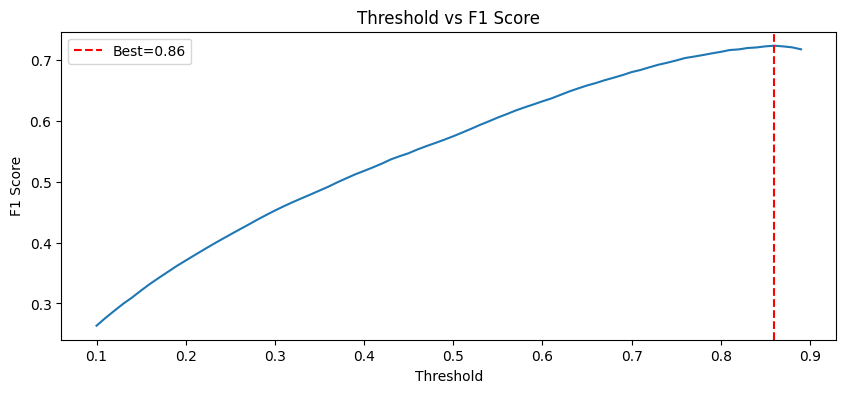

In [20]:
from sklearn.metrics import f1_score
import numpy as np

# Get probabilities
y_proba = lgb_smote.predict_proba(X)[:, 1]

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f'Best Threshold : {best_threshold:.2f}')
print(f'Best F1 Score  : {best_f1:.4f}')

# Plot
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold vs F1 Score')
plt.legend()
plt.show()

In [21]:
# Apply best threshold on test predictions
test_proba = lgb_smote.predict_proba(test_fe)[:, 1]
test_preds_tuned = (test_proba >= best_threshold).astype(int)

print('Prediction distribution:')
print(pd.Series(test_preds_tuned).value_counts())

submission_smote = pd.DataFrame({
    'ID': test['ID'].values,
    'target': test_preds_tuned
})
submission_smote.to_csv('submission_smote_tuned.csv', index=False)
print('Saved: submission_smote_tuned.csv')

Prediction distribution:
0    406978
1      2878
Name: count, dtype: int64
Saved: submission_smote_tuned.csv


In [22]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    scale_pos_weight=scale_pos,
    eval_metric='F1',
    random_seed=42,
    verbose=100
)
cat_model.fit(X_smote, y_smote)

cat_train_preds = cat_model.predict(X)
cat_test_preds  = cat_model.predict(test_fe)

print('=== CatBoost Train Report ===')
print(classification_report(y, cat_train_preds, digits=4))

0:	learn: 0.9963126	total: 539ms	remaining: 4m 28s
100:	learn: 0.9986372	total: 45s	remaining: 2m 57s
200:	learn: 0.9989500	total: 1m 30s	remaining: 2m 14s
300:	learn: 0.9990840	total: 2m 14s	remaining: 1m 28s
400:	learn: 0.9991126	total: 2m 53s	remaining: 42.7s
499:	learn: 0.9991127	total: 3m 30s	remaining: 0us
=== CatBoost Train Report ===
              precision    recall  f1-score   support

           0     1.0000    0.7994    0.8885   1625386
           1     0.0412    0.9976    0.0791     14038

    accuracy                         0.8010   1639424
   macro avg     0.5206    0.8985    0.4838   1639424
weighted avg     0.9918    0.8010    0.8815   1639424



In [23]:
submission_cat = pd.DataFrame({
    'ID': test['ID'].values,
    'target': cat_test_preds
})
submission_cat.to_csv('submission_cat.csv', index=False)
print('Saved: submission_cat.csv')
print(submission_cat['target'].value_counts())

Saved: submission_cat.csv
target
0    325002
1     84854
Name: count, dtype: int64


In [24]:
# Combine all model probabilities
lgb_proba  = lgb_smote.predict_proba(test_fe)[:, 1]
xgb_proba  = xgb_model.predict_proba(test_fe)[:, 1]
cat_proba  = cat_model.predict_proba(test_fe)[:, 1]

# Average probabilities
ensemble_proba = (lgb_proba * 0.4 + xgb_proba * 0.3 + cat_proba * 0.3)
ensemble_preds = (ensemble_proba >= best_threshold).astype(int)

submission_ensemble = pd.DataFrame({
    'ID': test['ID'].values,
    'target': ensemble_preds
})
submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print('Saved: submission_ensemble.csv')
print(submission_ensemble['target'].value_counts())

Saved: submission_ensemble.csv
target
0    405653
1      4203
Name: count, dtype: int64
